# Pty-Chi subpixel Fourier shift sanity test

This notebook isolates the subpixel-shift math from the reconstruction loop while directly using Pty-Chi's implementation. It builds a complex, probe-tapered synthetic exit wave, creates a shifted exit wave with spline interpolation, and compares its Fourier transform against a shift produced by `ptychi.image_proc.shift_images(..., method="fourier")`.

The comparison is on the complex Fourier field. A pure translation ideally preserves diffraction intensity, so intensity-only agreement can look good even when the Fourier phase or shift convention is wrong.

In [1]:
import os

os.environ.setdefault("KMP_DUPLICATE_LIB_OK", "TRUE")
os.environ.setdefault("PYTORCH_ENABLE_MPS_FALLBACK", "1")

import numpy as np
from scipy import ndimage as ndi
import matplotlib.pyplot as plt
import torch
import ptychi.image_proc as ip

np.set_printoptions(precision=4, suppress=True)
plt.rcParams.update({
    "figure.dpi": 120,
    "image.cmap": "magma",
    "axes.grid": False,
})

In [2]:
def smooth_noise(rng, shape, sigma, scale=1.0):
    noise = rng.normal(size=shape).astype(np.float32)
    noise = ndi.gaussian_filter(noise, sigma=sigma, mode="wrap")
    noise = (noise - noise.mean()) / (noise.std() + 1e-12)
    return scale * noise


def make_synthetic_exit_wave(n=160, seed=7):
    rng = np.random.default_rng(seed)
    yy, xx = np.indices((n, n), dtype=np.float32)
    yc = (yy - (n - 1) / 2) / (n / 2)
    xc = (xx - (n - 1) / 2) / (n / 2)
    rr = np.hypot(xc, yc)

    probe_amp = np.exp(-((rr / 0.62) ** 6))
    probe_phase = 0.9 * xc - 0.55 * yc + 0.18 * (xc**2 - yc**2)

    object_amp = np.clip(1.0 + smooth_noise(rng, (n, n), sigma=4, scale=0.08), 0.75, 1.25)
    object_phase = 0.65 * smooth_noise(rng, (n, n), sigma=6) + 0.35 * np.sin(5.0 * xc + 2.0 * yc)

    return (probe_amp * object_amp) * np.exp(1j * (probe_phase + object_phase))


def shift_complex_by_interpolation(wave, shift_yx, order=3):
    # scipy.ndimage.shift uses output[y, x] = input[y - dy, x - dx].
    # The exit wave is probe-tapered, so constant boundaries are effectively zero.
    kwargs = dict(
        shift=shift_yx,
        order=order,
        mode="constant",
        cval=0.0,
        prefilter=order > 1,
    )
    return ndi.shift(wave.real, **kwargs) + 1j * ndi.shift(wave.imag, **kwargs)


def shift_complex_with_ptychi(wave, shift_yx):
    wave_t = torch.as_tensor(wave[None], dtype=torch.complex64)
    shift_t = torch.as_tensor([shift_yx], dtype=torch.float32)
    shifted_t = ip.shift_images(
        wave_t,
        shift_t,
        method="fourier",
        adjoint=False,
        pad=0,
    )
    return shifted_t[0].detach().cpu().numpy()


def fft_centered(wave):
    return np.fft.fftshift(np.fft.fft2(wave))


def relative_l2(candidate, reference):
    return np.linalg.norm(candidate - reference) / np.linalg.norm(reference)


def masked_phase_rmse(candidate, reference, mask_fraction=0.03):
    amplitude = np.abs(reference)
    mask = amplitude > mask_fraction * amplitude.max()
    phase_residual = np.angle(candidate[mask] * np.conj(reference[mask]))
    return np.sqrt(np.mean(phase_residual**2))

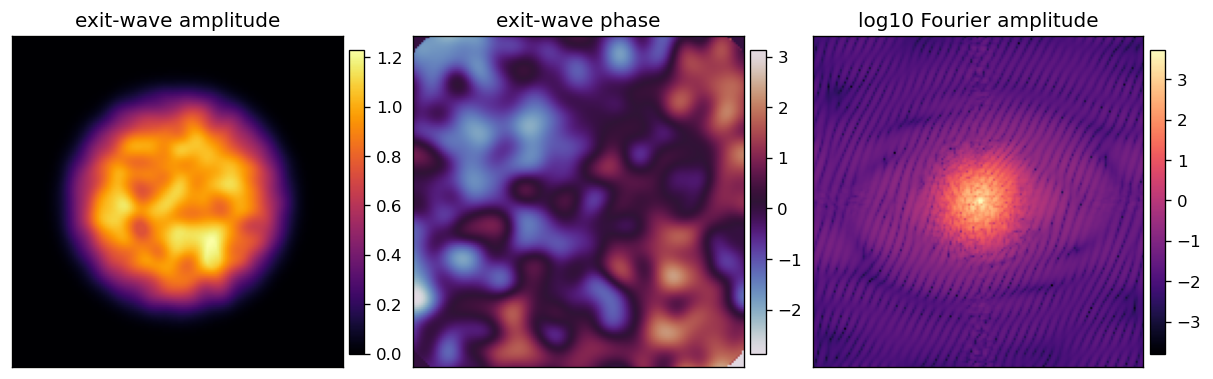

In [3]:
exit_wave = make_synthetic_exit_wave()

fig, axes = plt.subplots(1, 3, figsize=(10, 3.2), constrained_layout=True)
images = [
    (np.abs(exit_wave), "exit-wave amplitude", "inferno"),
    (np.angle(exit_wave), "exit-wave phase", "twilight"),
    (np.log10(np.abs(fft_centered(exit_wave)) + 1e-6), "log10 Fourier amplitude", "magma"),
]
for ax, (image, title, cmap) in zip(axes, images):
    im = ax.imshow(image, origin="lower", cmap=cmap)
    ax.set_title(title)
    ax.set_xticks([])
    ax.set_yticks([])
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.02)
plt.show()

In [4]:
shift_yx = (0.37, -0.58)
interp_order = 3

exit_interp = shift_complex_by_interpolation(exit_wave, shift_yx, order=interp_order)
fft_interp = np.fft.fft2(exit_interp)
exit_ptychi = shift_complex_with_ptychi(exit_wave, shift_yx)
fft_ptychi = np.fft.fft2(exit_ptychi)

metrics = {
    "relative exit-wave L2": relative_l2(exit_interp, exit_ptychi),
    "relative complex Fourier L2": relative_l2(fft_interp, fft_ptychi),
    "relative Fourier amplitude L2": relative_l2(np.abs(fft_interp), np.abs(fft_ptychi)),
    "relative diffraction-intensity L2": relative_l2(np.abs(fft_interp) ** 2, np.abs(fft_ptychi) ** 2),
    "masked Fourier phase RMSE (rad)": masked_phase_rmse(fft_interp, fft_ptychi),
}

print(f"subpixel shift (dy, dx): {shift_yx}")
print(f"interpolation order: {interp_order}")
print("Pty-Chi call: ip.shift_images(..., method='fourier', adjoint=False, pad=0)")
for name, value in metrics.items():
    print(f"{name:34s} {value:.3e}")

assert metrics["relative complex Fourier L2"] < 5e-4

subpixel shift (dy, dx): (0.37, -0.58)
interpolation order: 3
Pty-Chi call: ip.shift_images(..., method='fourier', adjoint=False, pad=0)
relative exit-wave L2              1.130e-04
relative complex Fourier L2        1.130e-04
relative Fourier amplitude L2      1.014e-04
relative diffraction-intensity L2  6.283e-07
masked Fourier phase RMSE (rad)    1.041e-06


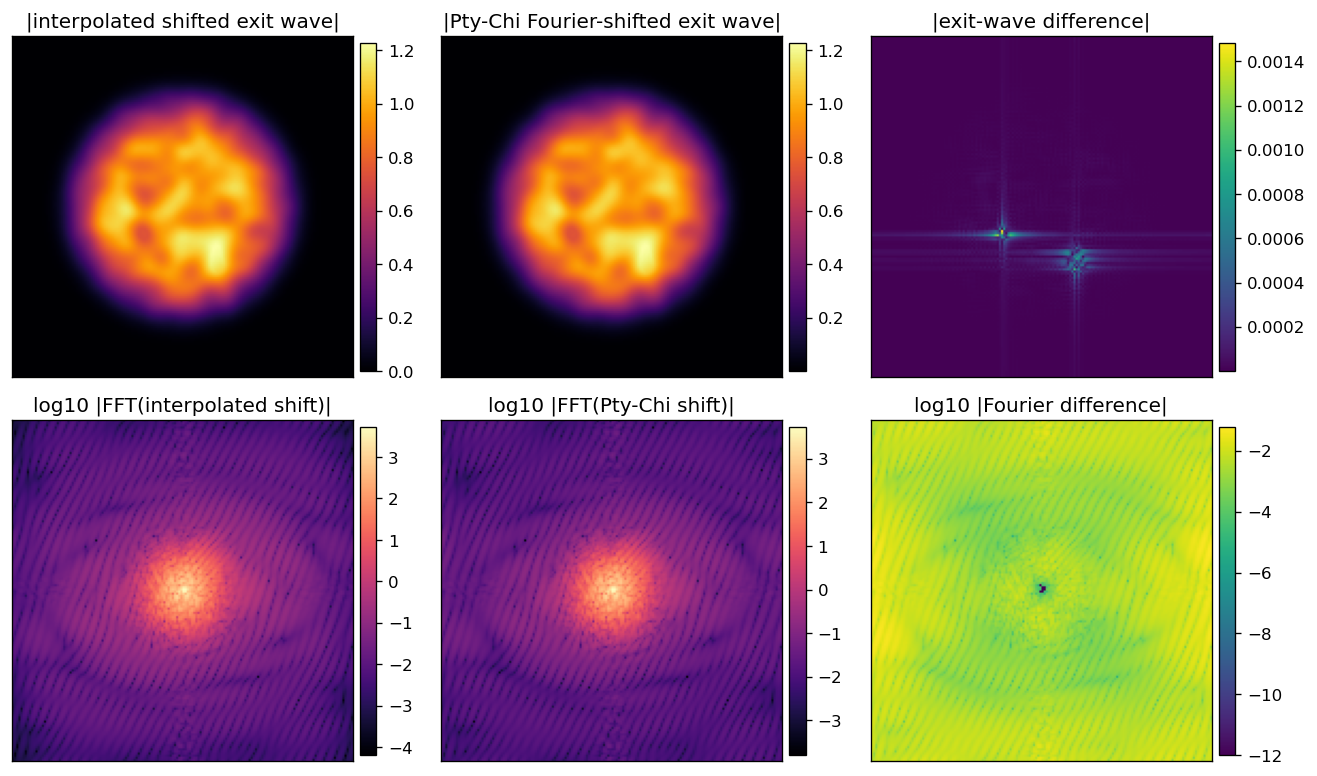

In [5]:
fft_interp_c = np.fft.fftshift(fft_interp)
fft_ptychi_c = np.fft.fftshift(fft_ptychi)
fft_residual_c = fft_interp_c - fft_ptychi_c
exit_residual = exit_interp - exit_ptychi

fig, axes = plt.subplots(2, 3, figsize=(11, 6.4), constrained_layout=True)
plot_specs = [
    (np.abs(exit_interp), "|interpolated shifted exit wave|", "inferno"),
    (np.abs(exit_ptychi), "|Pty-Chi Fourier-shifted exit wave|", "inferno"),
    (np.abs(exit_residual), "|exit-wave difference|", "viridis"),
    (np.log10(np.abs(fft_interp_c) + 1e-6), "log10 |FFT(interpolated shift)|", "magma"),
    (np.log10(np.abs(fft_ptychi_c) + 1e-6), "log10 |FFT(Pty-Chi shift)|", "magma"),
    (np.log10(np.abs(fft_residual_c) + 1e-12), "log10 |Fourier difference|", "viridis"),
]
for ax, (image, title, cmap) in zip(axes.ravel(), plot_specs):
    im = ax.imshow(image, origin="lower", cmap=cmap)
    ax.set_title(title)
    ax.set_xticks([])
    ax.set_yticks([])
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.02)
plt.show()

In [6]:
orders = [0, 1, 3, 5]
print("order | complex FFT rel. L2 | amplitude rel. L2 | intensity rel. L2 | phase RMSE")
print("------|---------------------|-------------------|--------------------|-----------")
order_errors = {}
for order in orders:
    shifted = shift_complex_by_interpolation(exit_wave, shift_yx, order=order)
    fft_shifted = np.fft.fft2(shifted)
    complex_error = relative_l2(fft_shifted, fft_ptychi)
    order_errors[order] = complex_error
    print(
        f"{order:5d} | "
        f"{complex_error:19.3e} | "
        f"{relative_l2(np.abs(fft_shifted), np.abs(fft_ptychi)):17.3e} | "
        f"{relative_l2(np.abs(fft_shifted) ** 2, np.abs(fft_ptychi) ** 2):18.3e} | "
        f"{masked_phase_rmse(fft_shifted, fft_ptychi):9.3e}"
    )

assert order_errors[3] < order_errors[1]

order | complex FFT rel. L2 | amplitude rel. L2 | intensity rel. L2 | phase RMSE
------|---------------------|-------------------|--------------------|-----------
    0 |           4.469e-02 |         1.018e-07 |          2.249e-07 | 9.296e-02
    1 |           3.753e-03 |         3.751e-03 |          7.361e-04 | 1.550e-04
    3 |           1.130e-04 |         1.014e-04 |          6.283e-07 | 1.041e-06
    5 |           8.790e-05 |         7.737e-05 |          4.504e-08 | 3.500e-08


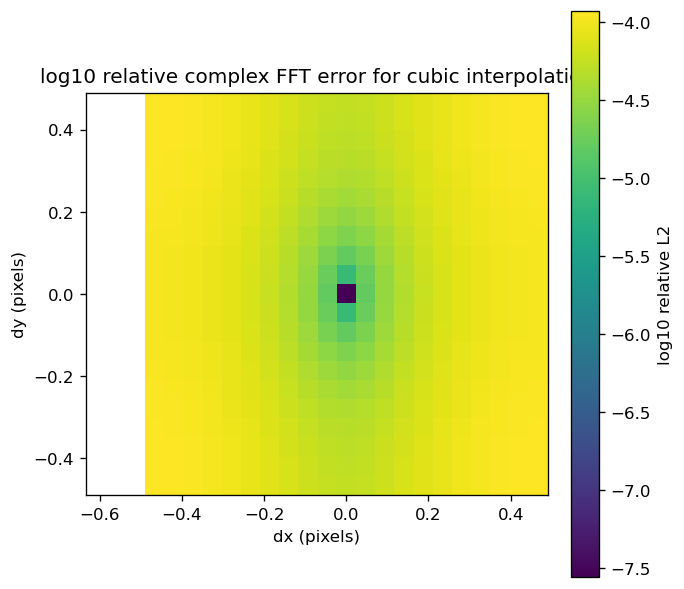

cubic interpolation error range over tested shifts: 2.770e-08 to 1.181e-04


In [7]:
shift_values = np.linspace(-0.49, 0.49, 21, dtype=np.float32)
error_grid = np.empty((len(shift_values), len(shift_values)), dtype=np.float32)

for iy, dy in enumerate(shift_values):
    for ix, dx in enumerate(shift_values):
        shifted = shift_complex_by_interpolation(exit_wave, (dy, dx), order=3)
        interp_fft = np.fft.fft2(shifted)
        ptychi_fft = np.fft.fft2(shift_complex_with_ptychi(exit_wave, (dy, dx)))
        error_grid[iy, ix] = relative_l2(interp_fft, ptychi_fft)

fig, ax = plt.subplots(figsize=(5.6, 4.8), constrained_layout=True)
im = ax.imshow(
    np.log10(error_grid),
    origin="lower",
    extent=[shift_values[0], shift_values[-1], shift_values[0], shift_values[-1]],
    aspect="equal",
    cmap="viridis",
)
ax.scatter([shift_yx[1]], [shift_yx[0]], s=55, facecolors="none", edgecolors="white", linewidths=1.5)
ax.set_xlabel("dx (pixels)")
ax.set_ylabel("dy (pixels)")
ax.set_title("log10 relative complex FFT error for cubic interpolation")
fig.colorbar(im, ax=ax, label="log10 relative L2")
plt.show()

print(f"cubic interpolation error range over tested shifts: {error_grid.min():.3e} to {error_grid.max():.3e}")

## Takeaway

The interpolated shifted exit wave and Pty-Chi's Fourier subpixel shift agree closely for this probe-tapered synthetic exit wave. The complex Fourier error is the useful check here; ideal diffraction intensities are nearly unchanged by a pure translation, so intensity-only agreement is not enough to validate the subpixel phase convention.